In [1]:
from torch.distributions import Poisson, Normal, MultivariateNormal
from gpzoo.gp import SVGP, MGGP_SVGP, VNNGP, MGGP_WSVGP
from gpzoo.kernels import batched_RBF, batched_MGGP_RBF
import torch
import matplotlib.pyplot as plt

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
torch.manual_seed(0)

In [3]:
N = 50

In [4]:
X1 = torch.randn((N,1))
groupsX1 = torch.zeros_like(X1.squeeze()).type(torch.long)
X2 = X1
groupsX2 = torch.ones_like(X2.squeeze()).type(torch.long)


In [8]:

kernel = batched_MGGP_RBF(sigma=1.0, lengthscale=1.0, group_diff_param=1e-2)
gp = MGGP_WSVGP(kernel=kernel, dim=1, M=100, jitter=5e-4, n_groups=2)
gp.Z = torch.nn.Parameter( torch.cat((X1, X2)))
gp.mu = torch.nn.Parameter(torch.zeros(2*N))
gp.Lu = torch.nn.Parameter(1.0*torch.eye(2*N))
gp.diagonal=False
gp.groupsZ = torch.nn.Parameter( (torch.cat((torch.zeros_like(X1), torch.ones_like(X2))).squeeze()).type(torch.long), requires_grad=False)

In [9]:
X_test = torch.linspace(-3, 3, 300)
group_test0 = torch.zeros_like(X_test).type(torch.long)
group_test1 = torch.ones_like(X_test).type(torch.long)

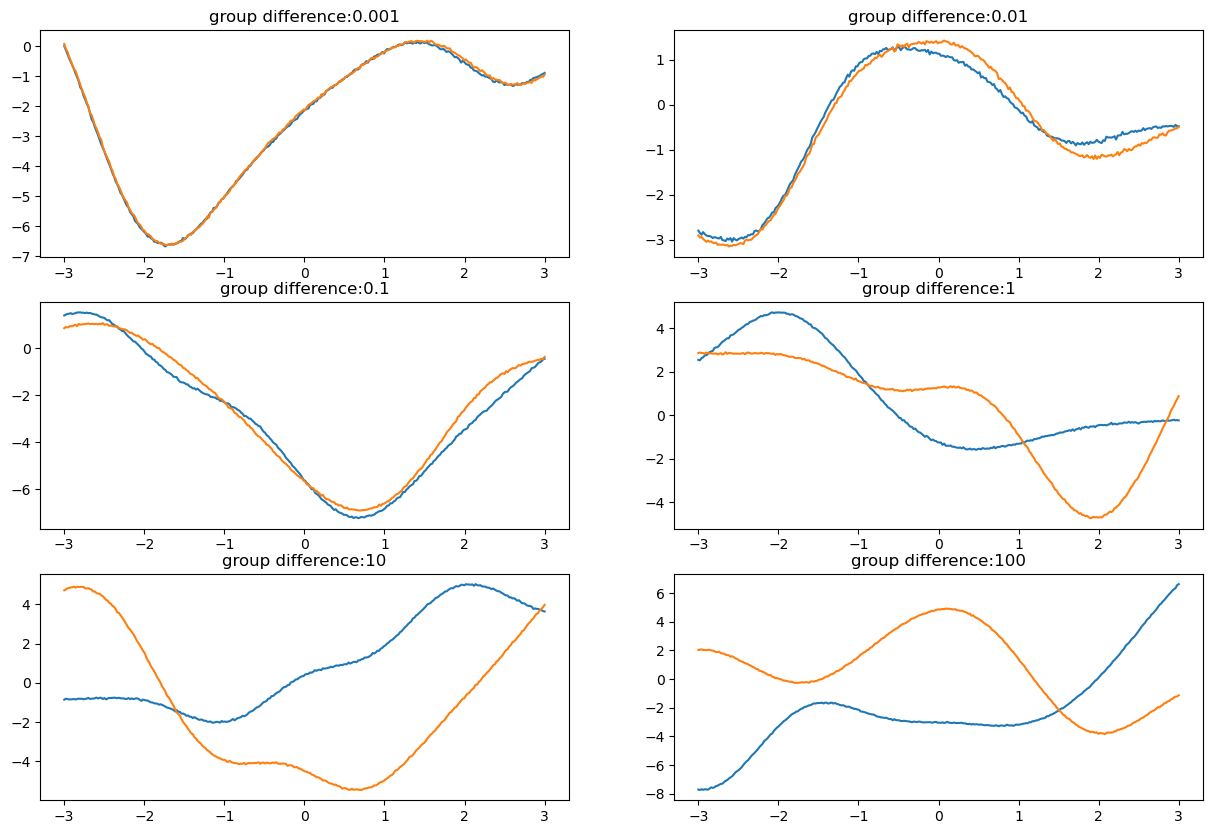

In [10]:
params = [1e-3, 1e-2, 1e-1, 1, 10, 100]
plt.figure(figsize=(15, 10))
for i in range(6):
    group_diff_param = params[i]
    gp.kernel.group_diff_param = torch.nn.Parameter(torch.tensor(group_diff_param), requires_grad=False)
    qF, _, _ = gp(X=torch.cat((X_test, X_test)), groupsX=torch.cat((group_test0, group_test1)), diag=False)
    sample = qF.sample()
    plt.subplot(3, 2,i+1)
    plt.title('group difference:'+str(group_diff_param))
    plt.plot(X_test, sample[:300])
    plt.plot(X_test, sample[300:])